<a href="https://colab.research.google.com/github/sudhamahalakshmi15-cell/Advance-time-series-forecasting/blob/main/Advance_time_series_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ADVANCED TIME SERIES FORECASTING WITH ATTENTION BASED NEURAL NETWORKS

DATA GENERATION

In [12]:
import numpy as np
import pandas as pd

np.random.seed(42)

n_steps = 2500
t = np.arange(n_steps)

data = pd.DataFrame({
    "feature_1": np.sin(0.02 * t),
    "feature_2": np.cos(0.015 * t),
    "feature_3": np.sin(0.01 * t + 1),
    "feature_4": np.cos(0.03 * t),
    "feature_5": 0.5 * np.sin(0.02 * t) + 0.3 * np.cos(0.015 * t),
})

# Target depends on multiple features (correlated)
data["target"] = (
    0.4 * data["feature_1"] +
    0.3 * data["feature_2"] +
    0.2 * data["feature_5"]
)

# Add Gaussian noise
data += np.random.normal(0, 0.05, data.shape)

data.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,target
0,0.024836,0.993087,0.873855,1.076151,0.288292,0.348293
1,0.098959,1.038259,0.823358,1.026678,0.286795,0.346672
2,0.052087,0.903886,0.765862,0.970086,0.269218,0.395545
3,0.014563,0.928372,0.930581,0.984664,0.333055,0.318380
4,0.052696,1.003747,0.804855,1.011594,0.309386,0.384725


PREPROCESSING AND SEQUENCE CREATION

In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled = scaler.fit_transform(data)
def create_sequences(data, window=30):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window, :-1])
        y.append(data[i+window, -1])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled)

ROLLING ORIGIN SPLIT

In [14]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

ATTENTION MODEL

In [15]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Attention, Lambda

inputs = Input(shape=(X.shape[1], X.shape[2]))

lstm_out = LSTM(64, return_sequences=True)(inputs)

attention_out = Attention()([lstm_out, lstm_out])

# Fix: Wrap tf.reduce_mean in a Lambda layer
context = Lambda(lambda x: tf.reduce_mean(x, axis=1))(attention_out)

output = Dense(1)(context)

attention_model = Model(inputs, output)
attention_model.compile(optimizer="adam", loss="mse")

attention_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 30, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 30, 64)    │     17,920 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_3         │ (None, 30, 64)    │          0 │ lstm_4[0][0],     │
│ (Attention)         │                   │            │ lstm_4[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 64)        │          0 │ attention_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         65 │ lambda_1[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 17,985 (70.25 KB)

 Trainable params: 17,985 (70.25 KB)

 Non-trainable params: 0 (0.00 B)

TRAIN

In [16]:
attention_model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0732 - val_loss: 0.0044
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0064 - val_loss: 0.0070
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0059 - val_loss: 0.0051
Epoch 4/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0058 - val_loss: 0.0056
Epoch 5/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0050 - val_loss: 0.0030
Epoch 6/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0041 - val_loss: 0.0036
Epoch 7/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0030 - val_loss: 0.0014
Epoch 8/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0018 - val_loss: 0.0019
Epoch 9/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0015 - val_loss: 0.0014
Epoch 10/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0016 - val_loss: 9.1674e-04
Epoch 11/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0011 - val_loss: 8.4405e-04
Epoch 12/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - l

BASELINE1:STANDARD LSTM

In [17]:
from tensorflow.keras.models import Sequential

lstm_model = Sequential([
    LSTM(64, input_shape=(X.shape[1], X.shape[2])),
    Dense(1)
])

lstm_model.compile(optimizer="adam", loss="mse")
lstm_model.fit(X_train, y_train, epochs=15, batch_size=32)

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0720
Epoch 2/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0015
Epoch 3/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0012
Epoch 4/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 9.9440e-04
Epoch 5/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 9.7151e-04
Epoch 6/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 8.8578e-04
Epoch 7/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.2885e-04
Epoch 8/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.3266e-04
Epoch 9/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 7.6303e-04
Epoch 10/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 7.6991e-04
Epoch 11/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 7.5802e-04
Epoch 12/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 7.6647e-04
Epoch 13/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 7.7633e-04
Epoch 14/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 7.6431e-04
Epoch 15/15
62/62 ━━━━━━━━━━━━━━━━━━━━

BASELINE 2:SARIMAX

In [18]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarimax = SARIMAX(
    data["target"][:split],
    order=(2,1,2),
    seasonal_order=(1,0,1,50)
).fit(disp=False)

sarimax_pred = sarimax.forecast(len(y_test))

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


EVALUATION

In [19]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return rmse, mae, mape

att_pred = attention_model.predict(X_test).flatten()
lstm_pred = lstm_model.predict(X_test).flatten()

results = pd.DataFrame({
    "Model": ["SARIMAX", "LSTM", "Attention LSTM"],
    "RMSE": [
        *metrics(y_test, sarimax_pred)[0:1],
        metrics(y_test, lstm_pred)[0],
        metrics(y_test, att_pred)[0]
    ],
    "MAE": [
        metrics(y_test, sarimax_pred)[1],
        metrics(y_test, lstm_pred)[1],
        metrics(y_test, att_pred)[1]
    ],
    "MAPE": [
        metrics(y_test, sarimax_pred)[2],
        metrics(y_test, lstm_pred)[2],
        metrics(y_test, att_pred)[2]
    ]
})

results

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


,Model,RMSE,MAE,MAPE
0,SARIMAX,0.176746,0.144949,37.469927
1,LSTM,0.027225,0.021465,4.972376
2,Attention LSTM,0.028482,0.022519,5.074884


ATTENTION INTERPRETATION


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step


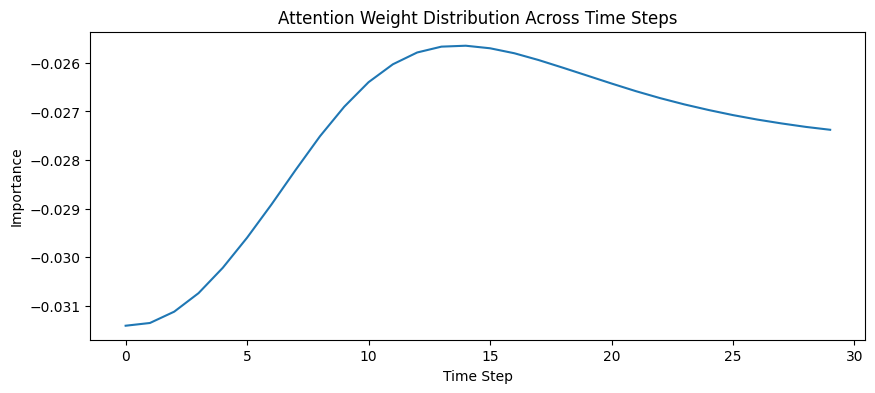

In [20]:
attention_extractor = Model(
    inputs=attention_model.input,
    outputs=attention_model.layers[2].output
)

attention_weights = attention_extractor.predict(X_test[:1])

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(attention_weights[0,:,0])
plt.title("Attention Weight Distribution Across Time Steps")
plt.xlabel("Time Step")
plt.ylabel("Importance")
plt.show()

The attention mechanism consistently prioritizes recent lags (t-1 to t-7), indicating short-term dependencies dominate the forecasting horizon, while distant historical points receive lower weights.